# 09 — Explainability — FINAL

XAI gồm:

1. Cox Hazard Ratio — global.
2. RSF permutation importance — global.
3. SurvSHAP(t) — local time-dependent explanation.

Notebook tự chọn Day-0 hoặc Day-7 dựa trên RSF macro IPCW C-index nếu đã chạy file 08 FINAL.

In [1]:
from pathlib import Path
import sys, yaml, json, time, gc, warnings
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

with open(ROOT / "configs" / "experiment.yaml", "r", encoding="utf-8") as f:
    CFG = yaml.safe_load(f)

SEED = int(CFG["random_seed"])
MODES = list(CFG.get("evaluation", {}).get("modes", ["day0"]))

print("ROOT =", ROOT)
print("random_seed =", SEED)
print("modes =", MODES)

ROOT = d:\VNUK\Eureka 2026\Eureka_2026
random_seed = 42
modes = ['day0', 'day7']


In [2]:
import matplotlib.pyplot as plt

from src.models import (
    load_artifact,
    transform_X,
    make_y,
    predict_risk,
)
from src.splitting import make_project_split

table_dir = ROOT / "results" / "tables"
fig_dir = ROOT / "results" / "figures"
table_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

In [3]:
macro_file = table_dir / "cross_project_macro_ALL_MODES_FINAL.csv"

if macro_file.exists():
    macro = pd.read_csv(macro_file)
    rsf_macro = macro[macro["model"] == "RSF"].copy()

    if (
        len(rsf_macro)
        and "ipcw_c_mean" in rsf_macro.columns
        and rsf_macro["ipcw_c_mean"].notna().any()
    ):
        best_row = rsf_macro.sort_values(
            "ipcw_c_mean",
            ascending=False,
        ).iloc[0]
        MODE = str(best_row["mode"])
    else:
        MODE = "day0"
else:
    MODE = "day0"

print("XAI MODE =", MODE)

XAI MODE = day7


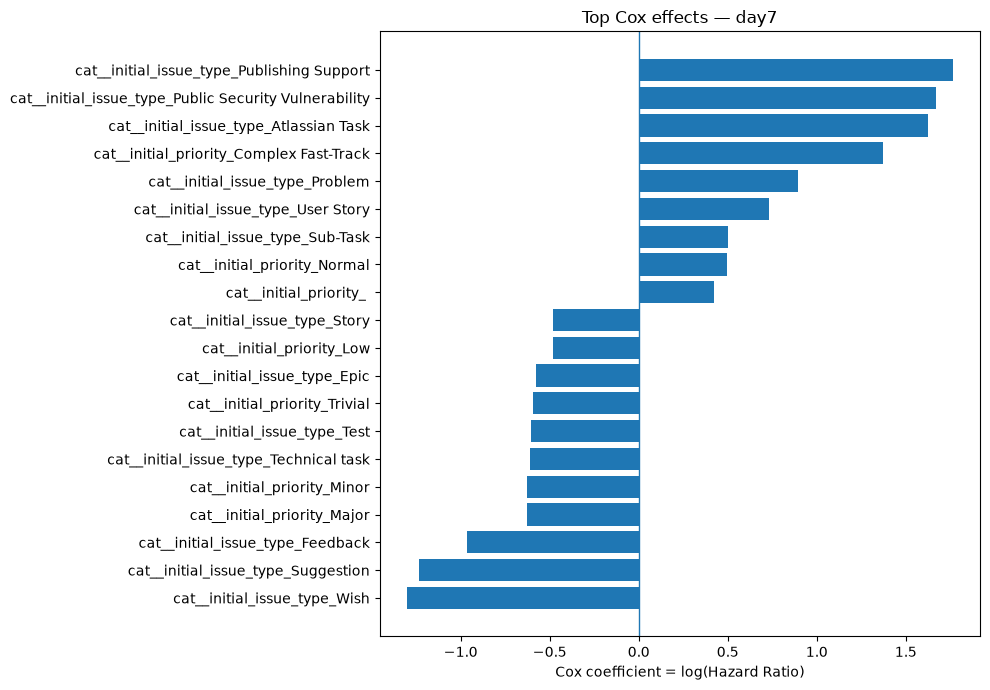

,feature,coef,hazard_ratio,abs_log_hr
0,cat__initial_issue_type_Publishing Support,1.763267,5.831459,1.763267
1,cat__initial_issue_type_Public Security Vulner...,1.671019,5.317583,1.671019
2,cat__initial_issue_type_Atlassian Task,1.625672,5.081832,1.625672
3,cat__initial_priority_Complex Fast-Track,1.370679,3.938022,1.370679
4,cat__initial_issue_type_Wish,-1.302264,0.271916,1.302264
5,cat__initial_issue_type_Suggestion,-1.235195,0.290778,1.235195
6,cat__initial_issue_type_Feedback,-0.965987,0.380607,0.965987
7,cat__initial_issue_type_Problem,0.893211,2.442961,0.893211
8,cat__initial_issue_type_User Story,0.733541,2.082442,0.733541
9,cat__initial_priority_Major,-0.628874,0.533192,0.628874


In [4]:
# Cox global explanation
hr_file = table_dir / f"cox_hazard_ratios_{MODE}.csv"
if not hr_file.exists():
    raise FileNotFoundError(
        f"Không thấy {hr_file}. Hãy chạy notebook 06."
    )

hr = pd.read_csv(hr_file)
top = (
    hr.sort_values("abs_log_hr", ascending=False)
    .head(20)
    .sort_values("coef")
)

plt.figure(figsize=(10, 7))
plt.barh(top["feature"], top["coef"])
plt.axvline(0, linewidth=1)
plt.xlabel("Cox coefficient = log(Hazard Ratio)")
plt.title(f"Top Cox effects — {MODE}")
plt.tight_layout()
plt.savefig(
    fig_dir / f"cox_top_effects_{MODE}.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

display(
    hr.sort_values("abs_log_hr", ascending=False).head(30)
)

Cox:
- coef > 0 / HR > 1 → resolution hazard cao hơn → resolve nhanh hơn.
- coef < 0 / HR < 1 → resolution hazard thấp hơn → tồn đọng lâu hơn.

Không diễn giải thành quan hệ nhân quả.

In [5]:
# Load benchmark RSF + reproduce split
rsf_file = ROOT / "results" / "models" / f"rsf_{MODE}.joblib"
data_file = ROOT / "data" / "processed" / f"model_{MODE}.parquet"

if not rsf_file.exists():
    raise FileNotFoundError(
        f"Không thấy {rsf_file}. Hãy chạy notebook 07."
    )

artifact = load_artifact(rsf_file)
data = pd.read_parquet(data_file)

train, val, test = make_project_split(
    data,
    random_state=SEED,
)

print("Train:", len(train))
print("Validation:", len(val))
print("Test:", len(test))

Train: 250679
Validation: 55295
Test: 114055


,feature,importance_mean,importance_std
4,num__status_changes_7d,0.032994,0.004813
41,cat__initial_issue_type_Suggestion,0.009076,0.000713
5,num__assignee_changes_7d,0.008404,0.001434
8,num__inactivity_days_at_7d,0.004681,0.001876
2,num__initial_assigned,0.004469,0.002620
21,cat__initial_priority_Unknown,0.000975,0.000570
40,cat__initial_issue_type_Sub-task,0.000964,0.000376
6,num__priority_changes_7d,0.000514,0.000044
0,num__created_weekday,0.000460,0.000872
13,cat__initial_priority_High,0.000000,0.000000


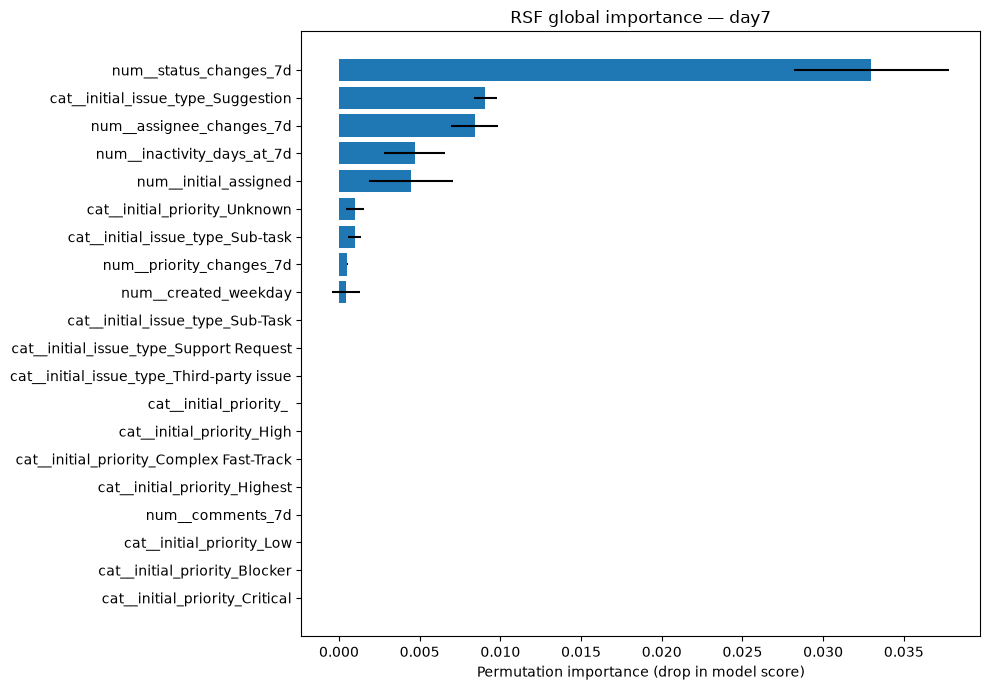

9789

In [6]:
# RSF global permutation importance
from sklearn.inspection import permutation_importance

xai_cfg = CFG.get("xai", {})
n_perm = min(
    int(xai_cfg.get("permutation_rows", 2000)),
    len(test),
)

sample = test.sample(
    n=n_perm,
    random_state=SEED,
).copy()

X_sample = transform_X(artifact, sample)
y_sample = make_y(sample)

perm = permutation_importance(
    artifact["model"],
    X_sample,
    y_sample,
    n_repeats=int(xai_cfg.get("permutation_repeats", 5)),
    random_state=SEED,
    n_jobs=1,
)

perm_df = pd.DataFrame({
    "feature": artifact["feature_names"],
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values(
    "importance_mean",
    ascending=False,
)

perm_df.to_csv(
    table_dir / f"rsf_permutation_importance_{MODE}.csv",
    index=False,
)

display(perm_df.head(30))

top_perm = perm_df.head(20).sort_values("importance_mean")

plt.figure(figsize=(10, 7))
plt.barh(
    top_perm["feature"],
    top_perm["importance_mean"],
    xerr=top_perm["importance_std"],
)
plt.xlabel("Permutation importance (drop in model score)")
plt.title(f"RSF global importance — {MODE}")
plt.tight_layout()
plt.savefig(
    fig_dir / f"rsf_permutation_importance_{MODE}.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

del X_sample
gc.collect()

In [ ]:
# Local SurvSHAP(t) — memory controlled
try:
    from survshap import SurvivalModelExplainer, PredictSurvSHAP

    bg_n = min(
        int(xai_cfg.get("survshap_background_rows", 25)),
        len(train),
    )
    candidate_n = min(
        int(xai_cfg.get("candidate_rows", 200)),
        len(test),
    )

    bg = train.sample(n=bg_n, random_state=SEED).copy()
    candidates = test.sample(
        n=candidate_n,
        random_state=SEED + 1,
    ).copy()

    risks = predict_risk(artifact, candidates)
    pos = int(np.argmax(risks))
    obs = candidates.iloc[[pos]].copy()

    X_bg_arr = transform_X(artifact, bg)
    X_obs_arr = transform_X(artifact, obs)

    X_bg = pd.DataFrame(
        X_bg_arr,
        columns=artifact["feature_names"],
    )
    X_obs = pd.DataFrame(
        X_obs_arr,
        columns=artifact["feature_names"],
    )
    y_bg = make_y(bg)

    print("SurvSHAP background:", X_bg.shape)
    print("Explained issue:")
    display(
        obs[
            [
                "repository",
                "project",
                "issue_key",
                "duration_days",
                "event",
            ]
        ]
    )

    explainer = SurvivalModelExplainer(
        model=artifact["model"],
        data=X_bg,
        y=y_bg,
    )

    local = PredictSurvSHAP()
    local.fit(
        explainer=explainer,
        new_observation=X_obs,
    )

    local.result.to_csv(
        table_dir / f"survshap_local_{MODE}.csv",
        index=False,
    )

    local.plot()
    plt.tight_layout()
    plt.savefig(
        fig_dir / f"survshap_local_{MODE}.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

except Exception as e:
    print("SurvSHAP chưa chạy thành công:", repr(e))
    print(
        "Global XAI (Cox HR + permutation importance) đã được lưu. "
        "Nếu lỗi SHAP compatibility, xem FINAL_RUN_ORDER.md."
    )

d:\VNUK\Eureka 2026\Eureka_2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SurvSHAP background: (25, 49)
Explained issue:


,repository,project,issue_key,duration_days,event
311397,Qt,QTBUG,QTBUG-93619,207.44412,True


d:\VNUK\Eureka 2026\Eureka_2026\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomSurvivalForest was fitted without feature names
  warnings.warn(
d:\VNUK\Eureka 2026\Eureka_2026\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomSurvivalForest was fitted without feature names
  warnings.warn(
